In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X_full = pd.read_csv("../outputs/fused_features.csv")

X_full.head()

,customer_unique_id,recency,frequency,monetary,nlp_1,nlp_2
0,0000366f3b9a7992bf8c76cfdf3221e2,0.157967,0.0,0.009603,7.955969,0.534592
1,0000f6ccb0745a6a4b88665a16c9f078,0.446429,0.0,0.001871,13.129206,11.164166
2,00053a61a98854899e70ed204dd4bafe,0.255495,0.0,0.028361,4.529376,4.633020
3,0005ef4cd20d2893f0d9fbd94d3c0d97,0.239011,0.0,0.007742,5.494314,1.528532
4,0006fdc98a402fceb4eb0ee528f6a8d4,0.564560,0.0,0.000971,5.508366,-0.480954


In [2]:
X = X_full.drop(columns=["customer_unique_id"])

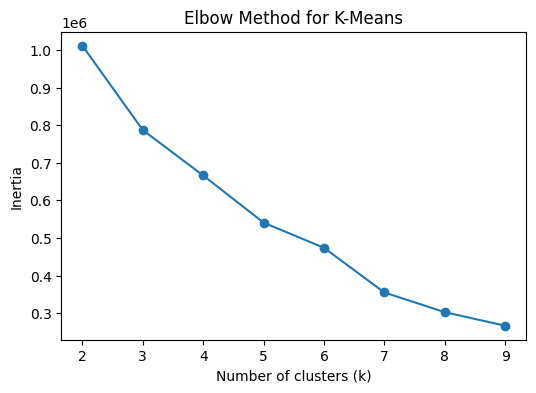

In [3]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [4]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

X_full["cluster"] = kmeans.fit_predict(X)

X_full["cluster"].value_counts()

cluster
1    19750
2     9302
0     6065
4     2589
5      830
3      786
Name: count, dtype: int64

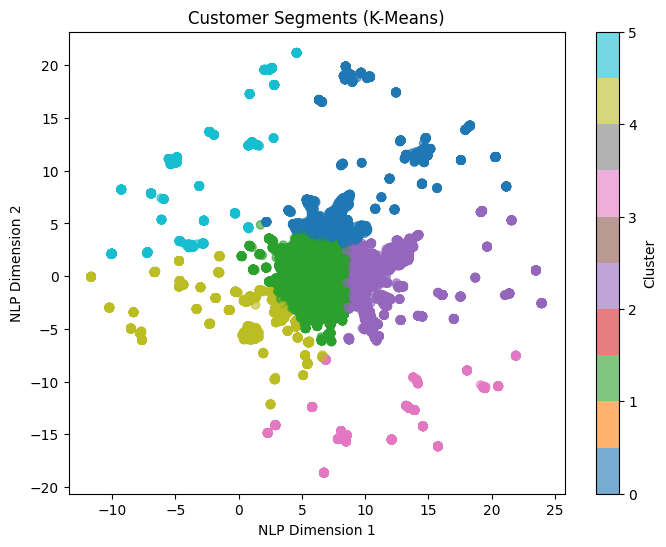

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_full["nlp_1"],
    X_full["nlp_2"],
    c=X_full["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("NLP Dimension 1")
plt.ylabel("NLP Dimension 2")
plt.title("Customer Segments (K-Means)")
plt.colorbar(label="Cluster")
plt.show()

In [6]:
cluster_summary = (
    X_full
    .groupby("cluster")
    .mean(numeric_only=True)
)

cluster_summary

,recency,frequency,monetary,nlp_1,nlp_2
cluster,,,,,
0,0.338095,0.003023,0.012656,8.210867,6.741739
1,0.338384,0.003072,0.011598,6.053300,0.009218
2,0.339445,0.002709,0.010893,11.074098,0.006092
3,0.343870,0.001696,0.008495,11.790302,-12.935176
4,0.348133,0.002240,0.009938,0.315120,-4.305697
5,0.353702,0.002570,0.009889,-2.927452,10.013042


In [7]:
persona_map = {
    0: "High-Value Enthusiasts",
    1: "Silent Loyal Customers",
    2: "Emerging Loyalists",
    3: "Dissatisfied / Churn-Risk Customers",
    4: "Fading Customers",
    5: "Dormant / One-Time Buyers"
}

X_full["persona"] = X_full["cluster"].map(persona_map)

In [8]:
X_full.to_csv(
    "../outputs/customer_personas.csv",
    index=False
)

print("Customer personas saved successfully.")

Customer personas saved successfully.
